# Baseball Lab 6: Probability, simulations, and object oriented programming continued

In today's exercises, you'll get practice:

1. Adding visualizations to the Baseball_Game object 
2. Simulating All-Star Baseball in Python
3. Using tree diagrams to calculate probabilities


#### Deadline

This assignment is due **Sunday March 22nd at 11pm** (i.e., the Sunday at the end of spring break). You can turn in the assignment up to 24 hours late for 90% credit (after that, the homework will only be accepted with a Dean's Extension). Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged. Refer to the policies page to learn more about how to learn cooperatively. You should start early so that you have time to get help if you're stuck. If you have questions, please post them to [Ed Discussion](https://edstem.org/us/courses/89102/discussion) (and answer others' questions too). 


## Getting started - downloading the data

In order to complete this lab, it is necessary to download a few files. Please run the code below **only once** to download data needed to complete the lab. To run the code, click in the cell below and press the play button (or press shift-enter). 


In [1]:
# Please run this code once to download the files you will need to complete the homework 

import YData_baseball

YData_baseball.download_image("strat_matt_vs_chad.jpg")


def download_retro_data(year):
    
    import os.path
    retro_file_name = str(year) + "plays.zip"
    if not os.path.isfile(retro_file_name):
        import requests
        retro_url = "https://www.retrosheet.org/downloads/plays/" + retro_file_name
        r = requests.get(retro_url )
        with open(retro_file_name, "wb") as f:
            f.write(r.content)
    else:
        print("File already downloaded, skipping download step.")


download_retro_data(2025)

The file `strat_matt_vs_chad.jpg` already exists.
If you would like to download a new copy of the file, please rename the existing copy of the file.
File already downloaded, skipping download step.


# Part 0: Quote and reaction to Astroball chapter 6 (5 points)

Please find an interesting quote from chapter 6 of Astroball and then write a ~one paragraph reaction to the quote below.

*Quote:*  ...

Reaction: ... 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Part 1: Adding visualizations to our Baseball_Game object

In lab 5, you created the `Baseball_Game` object that kept track of the state of a baseball game. You also created a special method that enables you to print the state of a baseball game using the `print()` function. However, it can be easier to understand, and more aesthetically pleasing, to see a visualizations of the state of a baseball game rather than just printing out the state. Let's now add a method to our `Baseball_Game` object that create a visualization of the state of the game using Matplotlib's graphics. 

**Exercise 1.1 (18 points):** Please add a method called `display_game(self, batter_name = "", center_string = "")` that displays a visualization of the state of a baseball game. To do this problem, complete the `display_game()` code in the cell below which has a partial implementation of this method. Then uncomment the top line of the cell which will write to a file called `baseball_game_with_graphics.py`. Your display of the state of the game should have the following properties: 

1. It should display a baseball diamond with red dots indicating whether a runner is on a particular base.
2. It should display the number of balls, strikes and outs.
3. It should display the inning and the score.
4. It should have an optional argument, `batter_name`, for the name of the current batter (e.g., the default is set to the empty string)
5. It should have an optional argument `center_string`, for a string displayed in the middle of the baseball diamond.

An example of such a graphic is shown below. 

<img src="https://raw.githubusercontent.com/emeyers/SDS1730/master/ClassMaterial/images/Baseball_Game_visualization.png">

Once you have created the `display_game()` method and written the file `baseball_game_with_graphics.py`, show that it works by displaying a baseball game in which David Ortiz is batting in the bottom of the 14th with the score tied at 4-4, there is a runner on 1st and 2nd base, with a count of 2 balls and 2 strikes, and the `center_string` is set to the value `Esteban Loaiza`.


In [3]:
#%%writefile baseball_game_with_graphics.py

# Once you code is complete, uncomment the line above to write you code to the file baseball_game_with_graphics.py

class Baseball_Game:

    # Please cut and paste in all your code for the Baseball_Game object from lab 5 here. 

    # You code should include the constructor (__init__ method) the __str__ method, along with all the other methods you wrote; 
    # i.e., update_half_inning, add_runs, add_outs, add_strike, add_runner_on_first, add_ball, add_single, add_double, add_triple, and add_home_run(self):

    # Once you have cut and pasted in your code, you can delete the comment above and then continue to implement the display_game method below.
        
    # Also, if you were not able to complete the code for the Baseball_Game object in lab 5, please email me and I will send you the code. 

    

    
    # Fill in the code below...
    
    def display_game(self, batter_name = "", center_string = ""):
        
        import matplotlib.pyplot as plt
        
        # draw the baseball diamond
        plt.plot([0, 1], [0, 1], color = "black");
        plt.plot([0, -1], [2, 1], color = "black");

        plt.axis("square")

        
        
        # put the runners on base
        plt.plot([1], [1], color = "red", marker=".", markersize=25);
       
        
            

        # add the balls, strikes and outs
        plt.text(.7, .3, "Balls: " + str(self.balls));


        
        # add the top and bottom of the innning 

        
        
        # add the scores


        
        # add the center string and batter string
        
        
        
        # turn off the axes to make the plot look better
        plt.axis("off");



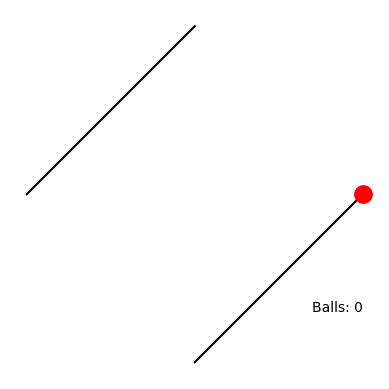

In [4]:

# Show that your display_game() method works by displaying the baseball game in which:
# David Ortiz is batting in the bottom of the 14th with the score tied at 4-4, 
# there is a runner on 1st and 2nd base, with a count of 2 balls and 2 strikes, 
# and the `center_string` is set to the value `Esteban Loaiza`.


import baseball_game_with_graphics as game

my_game = game.Baseball_Game()

my_game.inning = 14

...


my_game.display_game("David Ortiz", "Esteban Loaiza")


# Part 2: Simulating All-Star Baseball

For the second set of exercises we will use Python to simulate the [All-Star Baseball board game](https://en.wikipedia.org/wiki/All_Star_Baseball). To do this you will use the retrosheet play-by-play data set and you will simulate a game using the following steps: 

1. You will write a function `get_spinner_probabilities(retro_id)` that takes in a player's retrosheet ID, and returns a DataFrame with the proportion of times the player had different batting outcomes (e.g., got an out, hit a single, etc.). These proportions will be used to represent the areas of the All-Star baseball "spinners disks". 

2. You will write a function `get_lineups(game_id)` that extracts the batting lineup for a game. 

3. You will write a function `get_all_spinners(away_lineup, home_lineup)` that takes the lineups and returns a list of spinners for each batter in the lineup. 

4. You will then simulate a game by looping through the batting line-up, generating different random hitting outcomes for each player based on the spinners you created. You will use the `Baseball_Game` object from lab 5 to keep track of the state of the game and can then report the final score of the game.   

We use the retrosheet play-by-play data from the 2025 season to calculate our spinners. The code below reads in this data and shows the first few rows of the data. 


In [5]:
retro_data = pd.read_csv('2025plays.zip', low_memory=False)

retro_data.head()


,gid,event,inning,top_bot,vis_home,site,batteam,pitteam,score_v,score_h,...,pn,umphome,ump1b,ump2b,ump3b,umplf,umprf,date,gametype,pbp
0,CHN202503180,43/G34,1,0,0,TOK01,LAN,CHN,0,0,...,1,millb901,estam901,barrl901,libkj901,NaN,NaN,20250318,regular,full
1,CHN202503180,3/P34,1,0,0,TOK01,LAN,CHN,0,0,...,2,millb901,estam901,barrl901,libkj901,NaN,NaN,20250318,regular,full
2,CHN202503180,K,1,0,0,TOK01,LAN,CHN,0,0,...,3,millb901,estam901,barrl901,libkj901,NaN,NaN,20250318,regular,full
3,CHN202503180,W,1,1,1,TOK01,CHN,LAN,0,0,...,4,millb901,estam901,barrl901,libkj901,NaN,NaN,20250318,regular,full
4,CHN202503180,6/L6MD,1,1,1,TOK01,CHN,LAN,0,0,...,5,millb901,estam901,barrl901,libkj901,NaN,NaN,20250318,regular,full


## 2.1: Writing the get_spinner_probabilities() function 

In order to simulate the All-Star Baseball board game, we will need to write a function `get_spinner_probabilities(retro_id)` that takes in a player's `retrosheet_id` and returns a Series that has the proportion of times the player had different batting outcomes. In particular, the `get_spinner_probabilities(retro_id)` function should return a Series with the following information (where the type of information is given by the Series Index): 

1. `out`: the proportion of times the player got out (i.e., the player had a plate appearance and the number of outs increased)
2. `single`: the proportion of times the player hit a single
3. `double`: the proportion of times the player hit a double
4. `triple`: the proportion of times the player hit a triple
5. `hr`: the proportion of times the player hit a home run
6. `walk`: the proportion of times the player walked (including hit by pitch)
7. `roe`: the proportion of times the player reached on error (i.e., reached base due to an error by the fielder)


**Exercise 2.1 (15 points):** Please write the `get_spinner_probabilities(retro_id)` function by completing the following steps:

1. Reduce the retrosheet data to only the rows where the `batter` column matches the `retro_id` argument. Store this reduced data in a variable called `curr_player`. 

2. Add a new column to `curr_player` called `walk` that is the sum of the `walk` and `hbp` columns. This will give us the total number of times the player walked (including hit by pitch).

3. Add a new column to `curr_player` called `out` that is `True` if the player had a plate appearance and the number of outs increased (i.e., the player got out). This can be done by checking if the `pa` column is equal to 1 and the `outs_post` column is greater than the `outs_pre` column.

4. Create a Series called `event_counts` where the index has the values "out", "single", "double", "triple", "hr", "walk", "roe" and the values are the number of times each of these events occurred. To do this, you can select the relevant columns from the `curr_player` DataFrame and then use the `.sum()` method to get the counts of each event. 

5. Return a Series with the proportions of each event by dividing `event_counts` by the total number of events. 

Once you have the function written, use the code below to test that it works by running it on Aaron Judge's data (retrosheet id: judga001) to print out proportions of each event. 

In [6]:
def get_spinner_probabilities(retro_id):
      
    ...



# Test the code
get_spinner_probabilities('judga001')  

## 2.2: Extracting the batting lineup for a game

As a next step in simulating All-Star Baseball, let's write a function `get_lineups(game_id)` that takes in a game id and returns the batting lineups for the home and away teams. To keep this simple, the batting lineup for each team should be the first 9 batters who batted for each team. The function should return two DataFrames (in a tuple) where each DataFrame has a single column called `batter` that has the retro id for the 9 players in the batting lineup. 

**Exercise 2.2 (8 points):** Please write the `get_lineups(game_id)` function. Once you have the `get_lineups(game_id)` function written, use it to print the home lineup for the game id `'TOR202511010'` which corresponds to game 7 of the 2025 World Series between the Toronto Blue Jays and the Los Angeles Dodgers. 


In [7]:
def get_lineups(game_id):
    
    ...

    # return a tuple of the 
    





# write code that prints out the home lineup for the game id 'TOR202511010'



## 2.3: Getting the spinners for all batters

Let's now write a function `get_spinners(away_lineup, home_lineup)` that gets the spinner Series for all the batters in the lineups. This function should return two lists of 9 elements, called `away_spinners` and `home_spinners`, where the elements in the list contains the spinner probability Series for each batter in the lineup. To create these lists we can use the following steps:

1. Create two empty lists called `away_spinners` and `home_spinners` that will contain the spinner Series for each player in the batting lineup.

2. Use a for loop that loops 9 times, and in each iteration of the loop 
    a. Get the spinner Series for the current player in the batting lineup
    b. Append this spinner table to the list of spinner tables.

3. Return a tuple that contains the `away_spinners` and `home_spinners` lists.

**Exercise 2.3 (10 points):** Please write the `get_spinners(away_lineup, home_lineup)` function and test that the function works by printing the spinner for the first batter of the away team using the lineups calculated in exercise 2.2. 


In [8]:
def get_all_spinners(away_lineup, home_lineup):

    ...
    











# Test the code by printing the spinner for the first batter of the away team




## 2.4: Simulating an All-Star Baseball game

Now let's write a function `simulate_game(game_id)` that takes in a game id, and simulates a complete All-Star Baseball game. This function should work by: 

1. Creating a new `Baseball_Game` object (as was done in Lab 5) that will hold the state of the baseball game.

2. Getting the home and away lineups using the  `get_lineup(game_id)` function. 

3. Using the `get_all_spinners(away_lineup, home_lineup)` to get the spinners for both teams.

4. Creating two names `away_batter_num` and `home_batter_num` that are both initially set to 0 to indicate the index in the batting lineup that corresponds to the batters who will bat next for the away and the home teams. 

5. Create a while loop that loops until the `Baseball_Game` object indicates that it is the end of the game (similar to what was done in lab 4). Inside the loop your code should: 

a. Get the spinner for the current batter, and save it to the name `curr_spinner_data`. If it is the top of the inning, then you should get the current spinner for the away team and then increase the `away_batter_num` by 1. If the `away_batter_num` is greater than 8, it should be reset to 0 (Hint: using the modulus operator, %, could be useful here). Likewise, if it is the bottom of the inning, you should get the current spinner from the home team and update `home_batter_num`.

b. You should generate a play from the `curr_spinner_data` based on the player's batting probabilities using the `np.random.choice()` function. 

c. Based on the value of the random play returned, you should call the appropriate `Baseball_Game` object method to update the state of the baseball game (similar to what you did in lab 5).


**Exercise 2.4 (15 points):**  Please write the `simulate_game(game_id)` function.  Once you have the function written, use the function `np.random.seed(1730)` to set the random seed, and simulate the baseball game `'TOR202511010'`. Then print the final game state from this simulation using the `display_game()` method. Since this is a simulation of the last game of the World Series, in the answer section below please report who would have won the World Series if this simulation represented the real game 7 rather than just a simulation. 


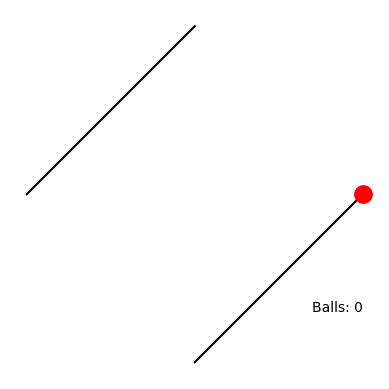

In [9]:
import baseball_game_with_graphics as game

def simulate_game(game_id):

    the_game = game.Baseball_Game()

    
    # Fill in the rest of the code below...
    
    ...






    

    return the_game


# Simulate the game 'TOR202511010'
# Do not change the code below

np.random.seed(1730)

game_id = 'TOR202511010'

curr_game = simulate_game(game_id)


#print(curr_game)  # if didn't get the display_game() method working, just print out the end state of the game

curr_game.display_game()

**Answer**

If the simulation above was the real game 7 of the World Series, the Toronto Blue Jays would have won the World Series since they were the home team in the last game of the World Series. 


## 2.5: Running an additional simulation 

Now that we have code to run simulations, let's use it to explore an additional question. 

**Exercise 2.5 (7 points):** Please run an additional simulation (or set of simulations) to explore another topic you find interesting. For example, you could simulate what percentage of time the Los Angeles Dodgers would have beaten the Toronto Blue Jays in the World Series if they both had used the same batting lineups as in game 7 of the World Series and they had played 100 World Series. Or you could simulate how often a team that consisted of only Shohei Ohtani would win against a team that consisted of only Aaron Judge. In the answer section, report what you simulation shows

Note: there is a lot of flexibility here (and we will be lenient in the grading), so challenge yourself to whatever level you feel is appropriate. 


**Answer** 








# Part 3: Using tree diagrams to calculate the probabilities

As discussed in class, we can use tree diagrams to calculate the probability of particular events. Let's practice this now!


## 3.1: Calculating probabilities using tree diagrams for Stat-O-Matic


**Exercise 3.1 (15 points):** Below is an image of the Strat-O-Matic cards for when Matt Holliday is batting against the pitcher Chad Billingsley. Using this image, please draw a tree diagram calculating the probability that Matt Holliday will hit a double against Chad Billingsley. Once you have created this tree diagram drawing, take a photo of it and include the image in the Jupyter Notebook below. 

![stratomatic_image](strat_matt_vs_chad.jpg)



**Answer:** 





# 4. Reflection (3 points)

Please fill out the lab 5 reflection on Canvas to let us know how this lab, and the class overall, is going for you. 



# 5.  Submitting your work

Once you're finished filling in and running all cells, you should submit your assignment as a pdf on Gradescope. You can access Gradescope through Canvas on the left-side of the class home page. The problems in each lab assignment are numbered. When submitting on Gradescope, please **make sure to select the correct pages of your pdf that correspond to each problem**. Failure to mark pages correctly **will result in points being deducted** from your score.

To convert this Jupyter notebook document to a pdf please run the code in the cell below. This should produce a pdf document which should appear in the files tab on the left (you might need to refresh the files tab to see this file). You can then right click on this file (command click on a mac), to download this pdf document which you can upload to Gradescope. 

Please be sure to check that all the code and output are visible before submitting your pdf to Gradescope as **points will be deducted for missing code and output that is not visible** since we will not be able to grade this.

In [10]:
%%capture

!quarto render lab_06.ipynb --cache-refresh --to pdf 


#### Alternative submission instructions

If converting your Jupyter notebook to a pdf using the command in the cell above does not work, an alternative way to convert your Jupyter notebook is:

1.  Go to "File" at the top-left of your Jupyter Notebook
2.  Under "Download as" (or "Save and Export Notebook As...") and select "HTML (.html)"
3.  After the .html has downloaded, open it and then select "File" and "Print" (note you will not actually be printing)
4.  From the print window, select the option to save as a .pdf
